# Face Recognition System and Smart Image Management using Deep Learning

Snapwelt PVT LTD 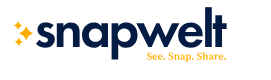
> **ArcFace · InsightFace · MTCNN · FAISS · DBSCAN · Streamlit**
>



In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## ① Check GPU

In [2]:
import subprocess
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(result.stdout if result.returncode == 0 else '⚠️  No GPU detected — switch to T4 GPU runtime!')


Thu May  7 14:49:51 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   31C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## ② Install Dependencies

In [3]:
%%capture
# Core vision & ML
!pip install -q opencv-python-headless mtcnn deepface

# InsightFace (ArcFace) — primary backend
!pip install -q insightface onnxruntime-gpu

# FAISS for fast vector search
!pip install -q faiss-gpu  # use faiss-cpu if no GPU

# Streamlit + tunnel
!pip install -q streamlit pyngrok

# Extras
!pip install -q scikit-learn plotly pandas

print('✅ All packages installed!')


## ③ Verify Installations

In [4]:
import sys, importlib

packages = {
    'cv2': 'OpenCV',
    'insightface': 'InsightFace (ArcFace)',
    'mtcnn': 'MTCNN',
    'deepface': 'DeepFace',
    'faiss': 'FAISS',
    'streamlit': 'Streamlit',
    'sklearn': 'Scikit-learn',
    'plotly': 'Plotly',
    'numpy': 'NumPy',
    'pandas': 'Pandas',
}

for mod, name in packages.items():
    try:
        m = importlib.import_module(mod)
        ver = getattr(m, '__version__', 'OK')
        print(f'  ✅ {name:<30} {ver}')
    except ImportError:
        print(f'  ❌ {name:<30} NOT INSTALLED')


  ✅ OpenCV                         4.13.0
  ✅ InsightFace (ArcFace)          0.7.3
  ✅ MTCNN                          OK
  ✅ DeepFace                       0.0.99
  ❌ FAISS                          NOT INSTALLED
  ✅ Streamlit                      1.57.0
  ✅ Scikit-learn                   1.6.1
  ✅ Plotly                         5.24.1
  ✅ NumPy                          2.0.2
  ✅ Pandas                         2.2.2


## ④ Write Streamlit App to Disk

In [5]:
import os
os.makedirs('/content/facesearch', exist_ok=True)

# Write the full app.py
app_code = '''
# ─── paste the full app.py content here, or it is written by the cell below ───
'''

print('Directory ready:', os.listdir('/content/facesearch') or '(empty — app.py written below)')


Directory ready: (empty — app.py written below)


In [6]:
%%writefile /content/facesearch/app.py
"""
Face Recognition System and Smart Image Management using Deep Learning (Snapwelt Pvt Ltd) by InsightFace (ArcFace) + FAISS + MTCNN + DBSCAN Clustering
"""

import streamlit as st
import numpy as np
import cv2
import os
import zipfile
import shutil
import pickle
import time
import pandas as pd
from PIL import Image
import io
import base64
from pathlib import Path
import tempfile
import math
import urllib.parse
import smtplib
import ssl
import http.client
from email.mime.multipart import MIMEMultipart
from email.mime.text import MIMEText
from email.mime.application import MIMEApplication
from sklearn.preprocessing import normalize
# ─── Page Config ──────────────────────────────────────────────────────────────
st.set_page_config(
    page_title="Face Recognition System and Smart Image Management using Deep Learning (Snapwelt Pvt Ltd)",
    page_icon="✨",
    layout="wide",
    initial_sidebar_state="expanded",
)

# ─── CSS Styling ──────────────────────────────────────────────────────────────
st.markdown("""
<style>
@import url('https://fonts.googleapis.com/css2?family=Sora:wght@300;400;600;700&family=Space+Mono:wght@400;700&display=swap');

:root {
    --bg: #0a0a0f;
    --surface: #12121a;
    --surface2: #1a1a26;
    --surface3: #1f1f30;
    --accent: #6c63ff;
    --accent2: #ff6584;
    --accent3: #43e97b;
    --accent4: #f7971e;
    --text: #e8e8f0;
    --muted: #6b6b8a;
    --border: #252535;
    --border2: #2e2e45;
}

html, body, [class*="css"] {
    font-family: 'Sora', sans-serif;
    background-color: var(--bg);
    color: var(--text);
}

.stApp { background: var(--bg); }

/* ── Hero Header ── */
.hero {
    text-align: center;
    padding: 2.5rem 0 1.5rem;
    background: linear-gradient(135deg, #0a0a0f 0%, #12121a 50%, #0d0d1a 100%);
    border-bottom: 1px solid var(--border);
    margin-bottom: 2rem;
}
.hero h1 {
    font-family: 'Space Mono', monospace;
    font-size: 2.8rem;
    font-weight: 700;
    background: linear-gradient(135deg, #6c63ff, #ff6584, #43e97b);
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
    background-clip: text;
    margin: 0;
    letter-spacing: -1px;
}
.hero p {
    color: var(--muted);
    font-size: 0.9rem;
    margin-top: 0.5rem;
    font-weight: 300;
    letter-spacing: 2px;
    text-transform: uppercase;
}
.hero-badge {
    display: inline-block;
    background: rgba(108,99,255,0.15);
    border: 1px solid rgba(108,99,255,0.4);
    border-radius: 20px;
    padding: 3px 14px;
    font-size: 0.72rem;
    font-family: 'Space Mono', monospace;
    color: var(--accent);
    margin: 0.3rem 0.2rem;
    letter-spacing: 1px;
}

/* ── Metric Cards ── */
.metric-card {
    background: var(--surface);
    border: 1px solid var(--border);
    border-radius: 14px;
    padding: 1.2rem 1.5rem;
    text-align: center;
    transition: all 0.25s;
}
.metric-card:hover { border-color: var(--accent); box-shadow: 0 0 20px rgba(108,99,255,0.12); }
.metric-card .value {
    font-family: 'Space Mono', monospace;
    font-size: 2rem;
    font-weight: 700;
    color: var(--accent);
    line-height: 1;
}
.metric-card .label {
    font-size: 0.7rem;
    color: var(--muted);
    text-transform: uppercase;
    letter-spacing: 1.5px;
    margin-top: 0.4rem;
}
.metric-card.green .value  { color: var(--accent3); }
.metric-card.orange .value { color: var(--accent4); }
.metric-card.red .value    { color: var(--accent2); }
.metric-card.blue .value   { color: #58c4f5; }

/* ── Match Cards ── */
.match-card {
    background: var(--surface);
    border: 1px solid var(--border);
    border-radius: 14px;
    overflow: hidden;
    transition: all 0.25s ease;
    margin-bottom: 0.5rem;
}
.match-card:hover {
    border-color: var(--accent);
    transform: translateY(-3px);
    box-shadow: 0 12px 32px rgba(108, 99, 255, 0.2);
}
.match-info {
    padding: 0.55rem 0.75rem;
    border-top: 1px solid var(--border);
}
.match-filename {
    font-size: 0.68rem;
    color: var(--muted);
    font-family: 'Space Mono', monospace;
    white-space: nowrap;
    overflow: hidden;
    text-overflow: ellipsis;
    margin-bottom: 0.2rem;
}
.match-score-bar {
    height: 4px;
    border-radius: 4px;
    background: var(--border2);
    overflow: hidden;
    margin-top: 0.3rem;
}
.match-score-fill {
    height: 100%;
    border-radius: 4px;
    background: linear-gradient(90deg, var(--accent), var(--accent3));
    transition: width 0.4s ease;
}
.score-badge {
    display: inline-block;
    padding: 2px 9px;
    border-radius: 12px;
    font-family: 'Space Mono', monospace;
    font-size: 0.7rem;
    font-weight: 700;
}
.score-high { background: rgba(67,233,123,0.15); color: var(--accent3); border: 1px solid var(--accent3); }
.score-mid  { background: rgba(247,151,30,0.15);  color: var(--accent4); border: 1px solid var(--accent4); }
.score-low  { background: rgba(255,101,132,0.15); color: var(--accent2); border: 1px solid var(--accent2); }

/* ── Query Box ── */
.query-box {
    background: var(--surface2);
    border: 1px solid var(--border);
    border-radius: 16px;
    padding: 1.2rem;
    height: 100%;
}

/* ── Cluster Card ── */
.cluster-header {
    background: var(--surface2);
    border: 1px solid var(--border2);
    border-radius: 12px;
    padding: 0.8rem 1.1rem;
    margin-bottom: 0.8rem;
    display: flex;
    align-items: center;
    gap: 0.8rem;
}
.cluster-id {
    font-family: 'Space Mono', monospace;
    font-size: 1.2rem;
    font-weight: 700;
    min-width: 40px;
    text-align: center;
}
.cluster-badge {
    background: rgba(108,99,255,0.15);
    border: 1px solid rgba(108,99,255,0.4);
    border-radius: 20px;
    padding: 2px 10px;
    font-size: 0.68rem;
    font-family: 'Space Mono', monospace;
    color: var(--accent);
}
.noise-badge {
    background: rgba(255,101,132,0.12);
    border: 1px solid rgba(255,101,132,0.4);
    border-radius: 20px;
    padding: 2px 10px;
    font-size: 0.68rem;
    font-family: 'Space Mono', monospace;
    color: var(--accent2);
}

/* ── Section Headers ── */
.section-title {
    font-family: 'Space Mono', monospace;
    font-size: 0.75rem;
    color: var(--accent);
    text-transform: uppercase;
    letter-spacing: 2.5px;
    border-bottom: 1px solid var(--border);
    padding-bottom: 0.5rem;
    margin: 1.5rem 0 1rem;
}

/* ── Info Panel ── */
.info-panel {
    background: var(--surface2);
    border: 1px solid var(--border);
    border-radius: 12px;
    padding: 1.2rem;
    font-size: 0.82rem;
    color: var(--muted);
    line-height: 1.9;
}
.info-panel b { color: var(--text); }

/* ── Status Pills ── */
.status-pill {
    display: inline-block;
    padding: 4px 14px;
    border-radius: 20px;
    font-size: 0.72rem;
    font-family: 'Space Mono', monospace;
    letter-spacing: 1px;
}
.status-ready  { background: rgba(67,233,123,0.15); border: 1px solid var(--accent3); color: var(--accent3); }
.status-empty  { background: rgba(255,101,132,0.12); border: 1px solid var(--accent2); color: var(--accent2); }

/* ── File Uploader ── */
div[data-testid="stFileUploader"] {
    background: var(--surface2);
    border: 1.5px dashed var(--border);
    border-radius: 12px;
    transition: border-color 0.2s;
}
div[data-testid="stFileUploader"]:hover { border-color: var(--accent); }

/* ── Sidebar ── */
section[data-testid="stSidebar"] {
    background: var(--surface) !important;
    border-right: 1px solid var(--border);
}
section[data-testid="stSidebar"] .stMarkdown h3 {
    color: var(--accent);
    font-family: 'Space Mono', monospace;
    font-size: 0.78rem;
    letter-spacing: 2px;
    text-transform: uppercase;
    border-bottom: 1px solid var(--border);
    padding-bottom: 0.4rem;
    margin-top: 1.5rem;
}

/* ── Buttons ── */
.stButton > button {
    background: linear-gradient(135deg, var(--accent), #8b85ff);
    color: white;
    border: none;
    border-radius: 8px;
    font-family: 'Space Mono', monospace;
    font-size: 0.8rem;
    letter-spacing: 1px;
    padding: 0.6rem 1.4rem;
    width: 100%;
    transition: all 0.2s;
}
.stButton > button:hover {
    transform: translateY(-1px);
    box-shadow: 0 6px 20px rgba(108, 99, 255, 0.4);
}

/* ── Divider ── */
.fancy-divider {
    border: none;
    border-top: 1px solid var(--border);
    margin: 1.5rem 0;
}

/* ── Table ── */
.stDataFrame { border-radius: 10px; overflow: hidden; }

/* ── Expander ── */
details { background: var(--surface2) !important; border-radius: 10px !important; border: 1px solid var(--border) !important; }

/* ── Empty State ── */
.empty-state {
    text-align: center;
    padding: 3.5rem 1rem;
    color: var(--muted);
}
.empty-state .icon { font-size: 3.5rem; margin-bottom: 1rem; }
.empty-state .msg  { font-size: 0.95rem; line-height: 1.6; }

/* ── Tabs ── */
.stTabs [data-baseweb="tab-list"] {
    background: var(--surface);
    border-radius: 10px;
    padding: 4px;
    gap: 4px;
    border: 1px solid var(--border);
}
.stTabs [data-baseweb="tab"] {
    background: transparent !important;
    color: var(--muted) !important;
    font-family: 'Space Mono', monospace;
    font-size: 0.75rem;
    border-radius: 7px;
    padding: 0.5rem 1rem;
}
.stTabs [aria-selected="true"] {
    background: var(--accent) !important;
    color: white !important;
}

/* ── Compare Row ── */
.compare-row {
    display: flex;
    align-items: stretch;
    gap: 1rem;
    margin-bottom: 1rem;
}

/* ── Analytics Stat Row ── */
.stat-row {
    display: flex;
    align-items: center;
    justify-content: space-between;
    padding: 0.5rem 0;
    border-bottom: 1px solid var(--border);
    font-size: 0.82rem;
}
.stat-row:last-child { border-bottom: none; }
.stat-key   { color: var(--muted); font-size: 0.78rem; }
.stat-value { font-family: 'Space Mono', monospace; color: var(--text); font-size: 0.78rem; }

/* ── Tooltip ── */
[title] { cursor: help; }
</style>
""", unsafe_allow_html=True)


# ─── Helper: image → base64 for HTML embedding ───────────────────────────────
def img_to_b64(img_bgr, max_size=300):
    """Convert BGR cv2 image to base64 PNG string, resized for display."""
    h, w = img_bgr.shape[:2]
    if max(h, w) > max_size:
        scale = max_size / max(h, w)
        img_bgr = cv2.resize(img_bgr, (int(w * scale), int(h * scale)))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    pil_img = Image.fromarray(img_rgb)
    buf = io.BytesIO()
    pil_img.save(buf, format="PNG")
    return base64.b64encode(buf.getvalue()).decode()


def path_to_b64(path, max_size=300):
    """Load image from path and return base64 string."""
    img = cv2.imread(str(path))
    if img is None:
        return None
    return img_to_b64(img, max_size)


# ─── Lazy Imports (heavy libs) ───────────────────────────────────────────────
@st.cache_resource(show_spinner=False)
def load_models():
    try:
        import insightface
        from insightface.app import FaceAnalysis
        app = FaceAnalysis(name='buffalo_l', providers=['CUDAExecutionProvider', 'CPUExecutionProvider'])
        app.prepare(ctx_id=0, det_size=(640, 640))
        return app, "insightface"
    except Exception as e:
        st.warning(f"InsightFace not available ({e}). Falling back to MTCNN + DeepFace.")
        try:
            from mtcnn import MTCNN
            from deepface import DeepFace
            detector = MTCNN()
            return (detector, DeepFace), "deepface"
        except Exception as e2:
            st.error(f"No face recognition backend available: {e2}")
            return None, None


def get_embedding_insightface(model, img_bgr):
    faces = model.get(img_bgr)
    if not faces:
        return None, None
    face = max(faces, key=lambda f: (f.bbox[2]-f.bbox[0])*(f.bbox[3]-f.bbox[1]))
    bbox = [int(x) for x in face.bbox]
    emb = face.normed_embedding.astype(np.float32)
    return emb, bbox


def get_embedding_deepface(models, img_bgr):
    detector, DeepFace = models
    try:
        result = DeepFace.represent(img_bgr, model_name="ArcFace", detector_backend="mtcnn",
                                    enforce_detection=True, align=True)
        emb = np.array(result[0]["embedding"], dtype=np.float32)
        emb = emb / (np.linalg.norm(emb) + 1e-8)
        region = result[0].get("facial_area", {})
        bbox = [region.get("x", 0), region.get("y", 0),
                region.get("x", 0)+region.get("w", 100), region.get("y", 0)+region.get("h", 100)]
        return emb, bbox
    except Exception:
        return None, None


def extract_embedding(model_pkg, model_type, img_bgr):
    if model_type == "insightface":
        return get_embedding_insightface(model_pkg, img_bgr)
    else:
        return get_embedding_deepface(model_pkg, img_bgr)


def cosine_similarity(a, b):
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-8))


def draw_bbox(img_bgr, bbox, color=(108, 99, 255), thickness=2):
    x1, y1, x2, y2 = [int(v) for v in bbox]
    cv2.rectangle(img_bgr, (x1, y1), (x2, y2), color, thickness)
    return img_bgr


def crop_face(img_bgr, bbox, padding=0.15):
    """Crop face region with optional padding."""
    x1, y1, x2, y2 = [int(v) for v in bbox]
    h, w = img_bgr.shape[:2]
    pw = int((x2 - x1) * padding)
    ph = int((y2 - y1) * padding)
    x1c = max(0, x1 - pw)
    y1c = max(0, y1 - ph)
    x2c = min(w, x2 + pw)
    y2c = min(h, y2 + ph)
    return img_bgr[y1c:y2c, x1c:x2c]


# ─── FAISS Index ──────────────────────────────────────────────────────────────
def build_faiss_index(embeddings):
    try:
        import faiss
        dim = embeddings.shape[1]
        index = faiss.IndexFlatIP(dim)
        index.add(embeddings)
        return index
    except ImportError:
        return None


# ─── CLUSTER COLOR PALETTE ────────────────────────────────────────────────────
CLUSTER_COLORS = [
    "#6c63ff", "#43e97b", "#ff6584", "#f7971e", "#58c4f5",
    "#b44fff", "#ff9a44", "#00d2ff", "#ff5e99", "#00c9a7",
    "#ffd700", "#fa8231", "#a29bfe", "#fd79a8", "#55efc4",
    "#e17055", "#74b9ff", "#81ecec", "#dfe6e9", "#636e72",
]

def get_cluster_color(cluster_id):
    if cluster_id == -1:
        return "#6b6b8a"
    return CLUSTER_COLORS[cluster_id % len(CLUSTER_COLORS)]


# ─── Session State Init ───────────────────────────────────────────────────────
def init_state():
    defaults = {
        "db": [],
        "faiss_index": None,
        "model_loaded": False,
        "model_pkg": None,
        "model_type": None,
        "results": [],
        "search_time": 0,
        "query_img_bgr": None,
        "query_bbox": None,
        "cluster_labels": None,
        "cluster_eps_used": None,
    }
    for k, v in defaults.items():
        if k not in st.session_state:
            st.session_state[k] = v

init_state()


# ─── Header ───────────────────────────────────────────────────────────────────
st.markdown("""
<div class="hero">
    <h1>✨ snapwelt  See. Snap. Share.</h1>
    <p>Face Recognition System and Smart Image Management using Deep Learning</p>
    <div style="margin-top:0.8rem;">
        <span class="hero-badge">ArcFace</span>
        <span class="hero-badge">InsightFace</span>
        <span class="hero-badge">MTCNN</span>
        <span class="hero-badge">FAISS</span>
        <span class="hero-badge">DBSCAN</span>
        <span class="hero-badge">Streamlit</span>
    </div>
</div>
""", unsafe_allow_html=True)


# ─── Sidebar ──────────────────────────────────────────────────────────────────
with st.sidebar:
    st.markdown("### ⚙ SYSTEM")

    if not st.session_state.model_loaded:
        if st.button("🚀 Initialize Models"):
            with st.spinner("Loading ArcFace / InsightFace…"):
                pkg, mtype = load_models()
                if pkg:
                    st.session_state.model_pkg = pkg
                    st.session_state.model_type = mtype
                    st.session_state.model_loaded = True
                    st.rerun()
    else:
        st.markdown(
            f'<span class="status-pill status-ready">✓ {st.session_state.model_type.upper()} READY</span>',
            unsafe_allow_html=True
        )
        backend_info = {
            "insightface": "ArcFace buffalo_l · 512-d · GPU",
            "deepface":    "DeepFace ArcFace · 512-d · CPU",
        }
        st.caption(backend_info.get(st.session_state.model_type, ""))

    st.markdown("### 🗄 DATABASE")
    db_count = len(st.session_state.db)
    status_cls = "green" if db_count > 0 else "red"
    st.markdown(
        f'<div class="metric-card {status_cls}"><div class="value">{db_count}</div>'
        f'<div class="label">Faces Indexed</div></div>',
        unsafe_allow_html=True
    )

    if st.session_state.db:
        if st.button("🗑 Clear Database"):
            st.session_state.db = []
            st.session_state.faiss_index = None
            st.session_state.results = []
            st.session_state.cluster_labels = None
            st.rerun()

        emb_data = {"db": st.session_state.db}
        buf = io.BytesIO()
        pickle.dump(emb_data, buf)
        st.download_button(
            "💾 Export Embeddings (.pkl)",
            data=buf.getvalue(),
            file_name="face_embeddings.pkl",
            mime="application/octet-stream"
        )

    st.markdown("### 🔧 SEARCH SETTINGS")
    threshold = st.slider(
        "Match Threshold", 0.0, 1.0, 0.45, 0.01,
        help="Cosine similarity threshold (0.45 = balanced, lower = more results)"
    )
    dup_threshold = st.slider(
        "Duplicate Threshold", 0.8, 1.0, 0.95, 0.01,
        help="Similarity above which two results are considered duplicates"
    )
    remove_dups = st.toggle("Remove Duplicates", value=False)
    top_k = st.slider("Max Results", 5, 100, 20, 5)
    use_faiss = st.toggle("Use FAISS (fast search)", value=True)

    st.markdown("### 🖼 DISPLAY SETTINGS")
    show_face_crop = st.toggle("Show Face Crops in Results", value=True,
                               help="Crop and display detected face region instead of full image")
    cols_per_row = st.select_slider("Result Columns", options=[2, 3, 4, 5, 6], value=4)
    show_score_bar = st.toggle("Show Score Bar", value=True)

    st.markdown("### 📂 IMPORT EMBEDDINGS")
    saved_emb = st.file_uploader("Load Embeddings (.pkl)", type=["pkl"])
    if saved_emb and st.button("📥 Load Embeddings"):
        data = pickle.load(saved_emb)
        st.session_state.db = data.get("db", [])
        if use_faiss and st.session_state.db:
            embs = np.array([r["emb"] for r in st.session_state.db])
            st.session_state.faiss_index = build_faiss_index(embs)
        st.success(f"✅ Loaded {len(st.session_state.db)} faces")
        st.rerun()

    st.markdown("---")
    st.caption("FaceSearch AI · MIT License · v2.0")


# ─── Main Tabs ────────────────────────────────────────────────────────────────
tab1, tab2, tab3 = st.tabs(["📁  BUILD DATABASE", "🔍  SEARCH FACES", "📊  ANALYTICS"])


# ══════════════════════════════════════════════════════════════════════════════
# TAB 1 – Build Database
# ══════════════════════════════════════════════════════════════════════════════
with tab1:
    col_left, col_right = st.columns([1.3, 1])

    with col_left:
        st.markdown('<div class="section-title">📤 Upload Dataset</div>', unsafe_allow_html=True)

        upload_type = st.radio("Upload Method", ["Multiple Images", "ZIP Archive"], horizontal=True)

        if upload_type == "ZIP Archive":
            dataset_file = st.file_uploader(
                "Upload ZIP file", type=["zip"],
                help="ZIP containing images (any folder structure supported)"
            )
        else:
            dataset_file = st.file_uploader(
                "Upload Images", type=["jpg", "jpeg", "png", "bmp", "webp"],
                accept_multiple_files=True,
                help="Select multiple image files at once"
            )

        c1, c2 = st.columns(2)
        with c1:
            batch_size = st.select_slider("Batch Size", options=[8, 16, 32, 64], value=16)
        with c2:
            max_img_dim = st.select_slider(
                "Max Image Dim", options=[640, 1024, 1280, 1920], value=1280,
                help="Resize images larger than this for speed"
            )

        build_btn = st.button("⚡ Process & Index Faces", use_container_width=True)

    with col_right:
        st.markdown('<div class="section-title">ℹ How It Works</div>', unsafe_allow_html=True)
        st.markdown("""
        <div class="info-panel">
        <b>Step 1:</b> Upload images or ZIP archive<br>
        <b>Step 2:</b> RetinaFace / MTCNN detects all faces<br>
        <b>Step 3:</b> ArcFace generates 512-d embeddings per face<br>
        <b>Step 4:</b> Embeddings stored in FAISS index<br>
        <b>Step 5:</b> Ready for sub-millisecond cosine search<br><br>
        <b>Supported formats:</b> JPG · PNG · BMP · WEBP<br>
        <b>Tip:</b> Use T4 GPU on Colab for 10× speed boost<br><br>
        <b>Threshold Guide:</b><br>
        &nbsp;&nbsp;0.30–0.40 → permissive (more results)<br>
        &nbsp;&nbsp;0.45 → balanced (default)<br>
        &nbsp;&nbsp;0.55–0.70 → strict (high confidence)
        </div>
        """, unsafe_allow_html=True)

        # Show current DB stats
        if st.session_state.db:
            st.markdown('<div class="section-title">📊 Current Database</div>', unsafe_allow_html=True)
            db = st.session_state.db
            exts = pd.Series([Path(r["filename"]).suffix.lower() for r in db]).value_counts()
            for ext, cnt in exts.items():
                st.markdown(
                    f'<div class="stat-row"><span class="stat-key">{ext}</span>'
                    f'<span class="stat-value">{cnt} files</span></div>',
                    unsafe_allow_html=True
                )

    # ── Build process ──
    if build_btn:
        if not st.session_state.model_loaded:
            st.error("⚠ Please initialize models first (sidebar → Initialize Models).")
        elif dataset_file is None or (isinstance(dataset_file, list) and len(dataset_file) == 0):
            st.error("⚠ Please upload files first.")
        else:
            tmpdir = tempfile.mkdtemp()
            image_paths = []

            with st.spinner("📦 Extracting images…"):
                if upload_type == "ZIP Archive":
                    zip_path = os.path.join(tmpdir, "dataset.zip")
                    with open(zip_path, "wb") as f:
                        f.write(dataset_file.read())
                    with zipfile.ZipFile(zip_path, "r") as zf:
                        zf.extractall(tmpdir)
                    for ext in ["jpg", "jpeg", "png", "bmp", "webp", "JPG", "JPEG", "PNG"]:
                        image_paths.extend(Path(tmpdir).rglob(f"*.{ext}"))
                else:
                    for uf in dataset_file:
                        fp = os.path.join(tmpdir, uf.name)
                        with open(fp, "wb") as f:
                            f.write(uf.read())
                        image_paths.append(Path(fp))

            if not image_paths:
                st.error("No valid images found.")
            else:
                st.info(f"📂 Found **{len(image_paths)}** images. Processing…")

                prog = st.progress(0)
                status = st.empty()
                new_records = []
                failed = 0

                for i, path in enumerate(image_paths):
                    prog.progress((i + 1) / len(image_paths))
                    status.markdown(
                        f'<small style="color:var(--muted)">Processing <code>{path.name}</code> '
                        f'({i+1}/{len(image_paths)})</small>',
                        unsafe_allow_html=True
                    )
                    try:
                        img = cv2.imread(str(path))
                        if img is None:
                            failed += 1
                            continue
                        h, w = img.shape[:2]
                        if max(h, w) > max_img_dim:
                            scale = max_img_dim / max(h, w)
                            img = cv2.resize(img, (int(w * scale), int(h * scale)))

                        emb, bbox = extract_embedding(
                            st.session_state.model_pkg, st.session_state.model_type, img
                        )
                        if emb is not None:
                            # Encode processed image to JPEG bytes
                            _, img_encoded = cv2.imencode('.jpg', img, [cv2.IMWRITE_JPEG_QUALITY, 85])
                            img_bytes = img_encoded.tobytes()
                            new_records.append({
                                "filename": path.name,
                                "emb": emb,
                                "bbox": bbox,
                                "img_bytes": img_bytes,
                            })
                        else:
                            failed += 1
                    except Exception:
                        failed += 1

                prog.progress(1.0)
                status.empty()

                st.session_state.db.extend(new_records)

                if use_faiss and st.session_state.db:
                    embs = np.array([r["emb"] for r in st.session_state.db])
                    st.session_state.faiss_index = build_faiss_index(embs)

                # Results summary
                c1, c2, c3 = st.columns(3)
                with c1:
                    st.markdown(
                        f'<div class="metric-card green"><div class="value">{len(new_records)}</div>'
                        f'<div class="label">Indexed</div></div>', unsafe_allow_html=True
                    )
                with c2:
                    st.markdown(
                        f'<div class="metric-card red"><div class="value">{failed}</div>'
                        f'<div class="label">No Face</div></div>', unsafe_allow_html=True
                    )
                with c3:
                    st.markdown(
                        f'<div class="metric-card blue"><div class="value">{len(st.session_state.db)}</div>'
                        f'<div class="label">Total DB</div></div>', unsafe_allow_html=True
                    )

                # Preview a few indexed faces
                if new_records:
                    st.markdown('<div class="section-title">🖼 Sample Indexed Faces</div>', unsafe_allow_html=True)
                    preview_n = min(8, len(new_records))
                    prev_cols = st.columns(preview_n)
                    for pi, rec in enumerate(new_records[:preview_n]):
                        with prev_cols[pi]:
                            # Decode stored bytes
                            file_bytes = np.frombuffer(rec["img_bytes"], np.uint8)
                            img = cv2.imdecode(file_bytes, cv2.IMREAD_COLOR)
                            if img is not None:
                                if show_face_crop and rec.get("bbox"):
                                    disp = crop_face(img, rec["bbox"])
                                else:
                                    if rec.get("bbox"):
                                        draw_bbox(img, rec["bbox"])
                                    disp = img
                                st.image(cv2.cvtColor(disp, cv2.COLOR_BGR2RGB),
                                         caption=rec["filename"][:12], use_container_width=True)

                shutil.rmtree(tmpdir, ignore_errors=True)


# ══════════════════════════════════════════════════════════════════════════════
# TAB 2 – Search Faces
# ══════════════════════════════════════════════════════════════════════════════
with tab2:
    if not st.session_state.db:
        st.markdown("""
        <div class="empty-state">
            <div class="icon">🗃</div>
            <div class="msg">Database is empty.<br>
            Go to <b>Build Database</b> tab and upload your images first.</div>
        </div>
        """, unsafe_allow_html=True)
    else:
        col_q, col_r = st.columns([1, 2.8])

        # ── Left: Query Panel ──
        with col_q:
            st.markdown('<div class="section-title">🎯 Query Image</div>', unsafe_allow_html=True)

            # ── Input method: Upload OR Camera ──
            q_input_tab1, q_input_tab2 = st.tabs(["📁 Upload Image", "📸 Use Camera"])

            query_img = None

            with q_input_tab1:
                query_file = st.file_uploader(
                    "Upload a face image",
                    type=["jpg", "jpeg", "png", "bmp", "webp"],
                    key="query_uploader",
                    help="Upload one face photo to search the database"
                )
                if query_file:
                    query_bytes = query_file.read()
                    query_np = np.frombuffer(query_bytes, np.uint8)
                    query_img = cv2.imdecode(query_np, cv2.IMREAD_COLOR)
                    st.session_state.query_img_bgr = query_img
                    query_rgb = cv2.cvtColor(query_img, cv2.COLOR_BGR2RGB)
                    st.image(query_rgb, caption="📷 Uploaded Query", use_container_width=True)

            with q_input_tab2:
                cam_snapshot = st.camera_input(
                    "Capture face from webcam",
                    key="cam_query_input",
                    help="Click the camera button to take a photo for face search"
                )
                if cam_snapshot:
                    cam_bytes = cam_snapshot.read()
                    cam_np = np.frombuffer(cam_bytes, np.uint8)
                    query_img = cv2.imdecode(cam_np, cv2.IMREAD_COLOR)
                    st.session_state.query_img_bgr = query_img
                    st.success("✅ Camera snapshot ready!")

            if query_img is not None:
                search_btn = st.button("🔍 Find Matches", use_container_width=True)

                if search_btn:
                    if not st.session_state.model_loaded:
                        st.error("Initialize models first (sidebar)!")
                    else:
                        with st.spinner("Detecting face & generating embedding…"):
                            q_emb, q_bbox = extract_embedding(
                                st.session_state.model_pkg,
                                st.session_state.model_type,
                                query_img
                            )
                            st.session_state.query_bbox = q_bbox

                        if q_emb is None:
                            st.error("❌ No face detected. Try a clearer frontal face image.")
                        else:
                            # Show detected face with bbox
                            q_vis = query_img.copy()
                            if q_bbox:
                                draw_bbox(q_vis, q_bbox, color=(108, 99, 255), thickness=3)
                            st.image(cv2.cvtColor(q_vis, cv2.COLOR_BGR2RGB),
                                     caption="✅ Face Detected", use_container_width=True)

                            # ── Search ──
                            t0 = time.time()
                            db = st.session_state.db
                            db_embs = np.array([r["emb"] for r in db])

                            if use_faiss and st.session_state.faiss_index is not None:
                                import faiss
                                q_norm = q_emb / (np.linalg.norm(q_emb) + 1e-8)
                                scores, idxs = st.session_state.faiss_index.search(
                                    q_norm.reshape(1, -1), min(top_k * 2, len(db))
                                )
                                scores, idxs = scores[0], idxs[0]
                                candidates = [
                                    (float(s), db[i])
                                    for s, i in zip(scores, idxs) if float(s) >= threshold
                                ]
                            else:
                                sims = [cosine_similarity(q_emb, r["emb"]) for r in db]
                                candidates = [
                                    (s, db[i])
                                    for i, s in enumerate(sims) if s >= threshold
                                ]
                                candidates.sort(key=lambda x: x[0], reverse=True)
                                candidates = candidates[:top_k * 2]

                            elapsed = time.time() - t0

                            # ── Duplicate removal ──
                            if remove_dups:
                                filtered = []
                                for score, rec in candidates:
                                    is_dup = any(
                                        cosine_similarity(rec["emb"], kept["emb"]) > dup_threshold
                                        for _, kept in filtered
                                    )
                                    if not is_dup:
                                        filtered.append((score, rec))
                                candidates = filtered

                            candidates = candidates[:top_k]
                            st.session_state["results"] = candidates
                            st.session_state["search_time"] = elapsed
                            st.rerun()

                # ── Face Crop Preview when crop mode on ──
                if show_face_crop and st.session_state.get("query_bbox") and query_img is not None:
                    q_img_stored = st.session_state.get("query_img_bgr")
                    if q_img_stored is not None and st.session_state.query_bbox:
                        face_crop = crop_face(q_img_stored, st.session_state.query_bbox)
                        if face_crop.size > 0:
                            st.image(
                                cv2.cvtColor(face_crop, cv2.COLOR_BGR2RGB),
                                caption="🔬 Cropped Face", use_container_width=True
                            )

        # ── Right: Results Panel ──
        with col_r:
            st.markdown('<div class="section-title">📋 Search Results</div>', unsafe_allow_html=True)

            if st.session_state.get("results") is not None and len(st.session_state.results) > 0:
                results = st.session_state.results
                elapsed = st.session_state.get("search_time", 0)

                # ── Summary Metrics ──
                m1, m2, m3, m4 = st.columns(4)
                with m1:
                    st.markdown(
                        f'<div class="metric-card green"><div class="value">{len(results)}</div>'
                        f'<div class="label">Matches</div></div>', unsafe_allow_html=True
                    )
                with m2:
                    best = results[0][0] if results else 0
                    cls = "green" if best >= 0.7 else ("orange" if best >= 0.5 else "red")
                    st.markdown(
                        f'<div class="metric-card {cls}"><div class="value">{best:.3f}</div>'
                        f'<div class="label">Best Score</div></div>', unsafe_allow_html=True
                    )
                with m3:
                    avg = np.mean([s for s, _ in results])
                    st.markdown(
                        f'<div class="metric-card"><div class="value">{avg:.3f}</div>'
                        f'<div class="label">Avg Score</div></div>', unsafe_allow_html=True
                    )
                with m4:
                    st.markdown(
                        f'<div class="metric-card blue"><div class="value">{elapsed*1000:.1f}ms</div>'
                        f'<div class="label">Search Time</div></div>', unsafe_allow_html=True
                    )

                st.markdown("<br>", unsafe_allow_html=True)

                # ── Comparison: Query vs Best Match ──
                if results and st.session_state.get("query_img_bgr") is not None:
                    with st.expander("🔗 Query vs Best Match Comparison", expanded=True):
                        cmp1, cmp_mid, cmp2 = st.columns([1, 0.15, 1])
                        with cmp1:
                            q_img = st.session_state.query_img_bgr.copy()
                            qb = st.session_state.get("query_bbox")
                            if show_face_crop and qb:
                                q_disp = crop_face(q_img, qb)
                            else:
                                if qb:
                                    draw_bbox(q_img, qb, color=(108, 99, 255), thickness=3)
                                q_disp = q_img
                            st.image(cv2.cvtColor(q_disp, cv2.COLOR_BGR2RGB),
                                     caption="🎯 Query Face", use_container_width=True)
                        with cmp_mid:
                            st.markdown(
                                '<div style="text-align:center;padding-top:4rem;'
                                'font-size:1.8rem;color:var(--accent);">⟷</div>',
                                unsafe_allow_html=True
                            )
                        with cmp2:
                            best_score, best_rec = results[0]
                            # Decode stored bytes
                            file_bytes = np.frombuffer(best_rec["img_bytes"], np.uint8)
                            best_img = cv2.imdecode(file_bytes, cv2.IMREAD_COLOR)
                            if best_img is not None:
                                if show_face_crop and best_rec.get("bbox"):
                                    best_disp = crop_face(best_img, best_rec["bbox"])
                                else:
                                    if best_rec.get("bbox"):
                                        draw_bbox(best_img, best_rec["bbox"],
                                                  color=(67, 233, 123), thickness=3)
                                    best_disp = best_img
                                score_color = "#43e97b" if best_score >= 0.7 else \
                                              "#f7971e" if best_score >= 0.5 else "#ff6584"
                                st.image(cv2.cvtColor(best_disp, cv2.COLOR_BGR2RGB),
                                         caption=f"🥇 Best Match · {best_score:.4f}",
                                         use_container_width=True)

                # ── Results Grid ──
                st.markdown(
                    f'<div style="color:var(--muted);font-size:0.78rem;margin-bottom:0.8rem;">'
                    f'Showing {len(results)} results sorted by similarity score</div>',
                    unsafe_allow_html=True
                )

                rows = [results[i:i+cols_per_row] for i in range(0, len(results), cols_per_row)]
                for row in rows:
                    grid_cols = st.columns(cols_per_row)
                    for j, (score, rec) in enumerate(row):
                        with grid_cols[j]:
                            # Decode stored bytes
                            file_bytes = np.frombuffer(rec["img_bytes"], np.uint8)
                            img = cv2.imdecode(file_bytes, cv2.IMREAD_COLOR)
                            if img is not None:
                                if show_face_crop and rec.get("bbox"):
                                    disp_img = crop_face(img, rec["bbox"])
                                else:
                                    img_copy = img.copy()
                                    if rec.get("bbox"):
                                        draw_bbox(img_copy, rec["bbox"],
                                                  color=(67, 233, 123), thickness=2)
                                    disp_img = img_copy

                                st.image(
                                    cv2.cvtColor(disp_img, cv2.COLOR_BGR2RGB),
                                    use_container_width=True
                                )

                                score_cls = "score-high" if score >= 0.7 else \
                                            "score-mid"  if score >= 0.5 else "score-low"
                                score_color = "#43e97b" if score >= 0.7 else \
                                              "#f7971e"  if score >= 0.5 else "#ff6584"
                                bar_pct = int(score * 100)

                                score_bar_html = ""
                                if show_score_bar:
                                    score_bar_html = (
                                        f'<div class="match-score-bar">'
                                        f'<div class="match-score-fill" style="width:{bar_pct}%;'
                                        f'background:linear-gradient(90deg,{score_color},{score_color}88);"></div>'
                                        f'</div>'
                                    )

                                st.markdown(
                                    f'<div class="match-info">'
                                    f'<div class="match-filename" title="{rec["filename"]}">'
                                    f'{rec["filename"]}</div>'
                                    f'<span class="score-badge {score_cls}">▲ {score:.4f}</span>'
                                    f'{score_bar_html}'
                                    f'</div>',
                                    unsafe_allow_html=True
                                )

                st.markdown("<br>", unsafe_allow_html=True)

                # ── Downloads ──
                dl1, dl2 = st.columns(2)
                with dl1:
                    df_out = pd.DataFrame([
                        {"filename": r["filename"], "similarity": f"{s:.4f}"}
                        for s, r in results
                    ])
                    csv_data = df_out.to_csv(index=False)
                    st.download_button(
                        "⬇ Download CSV", data=csv_data,
                        file_name="face_search_results.csv", mime="text/csv",
                        use_container_width=True
                    )
                with dl2:
                    buf = io.BytesIO()
                    with zipfile.ZipFile(buf, "w") as zf:
                        for s, rec in results:
                            # Write stored bytes directly
                            zf.writestr(rec["filename"], rec["img_bytes"])
                    buf.seek(0)
                    st.download_button(
                        "📦 Download Images ZIP", data=buf.getvalue(),
                        file_name="matched_faces.zip", mime="application/zip",
                        use_container_width=True
                    )

            elif "results" in st.session_state and len(st.session_state.results) == 0:
                st.markdown("""
                <div class="empty-state">
                    <div class="icon">🔎</div>
                    <div class="msg">No matches found above threshold.<br>
                    Try lowering the <b>Match Threshold</b> in the sidebar.</div>
                </div>
                """, unsafe_allow_html=True)
            else:
                st.markdown("""
                <div class="empty-state">
                    <div class="icon">👤</div>
                    <div class="msg">Upload a query image on the left<br>
                    and click <b>Find Matches</b> to search.</div>
                </div>
                """, unsafe_allow_html=True)


# ══════════════════════════════════════════════════════════════════════════════
# TAB 3 – Analytics
# ══════════════════════════════════════════════════════════════════════════════
with tab3:
    if not st.session_state.db:
        st.markdown("""
        <div class="empty-state">
            <div class="icon">📊</div>
            <div class="msg">Build a database first to view analytics.</div>
        </div>
        """, unsafe_allow_html=True)
    else:
        db = st.session_state.db
        filenames = [r["filename"] for r in db]
        embs = np.array([r["emb"] for r in db])

        # ── Top Summary ──
        st.markdown('<div class="section-title">📈 Database Overview</div>', unsafe_allow_html=True)
        ov1, ov2, ov3, ov4 = st.columns(4)
        norms = np.linalg.norm(embs, axis=1)
        exts = pd.Series([Path(r["filename"]).suffix.lower() for r in db]).value_counts()
        with ov1:
            st.markdown(
                f'<div class="metric-card blue"><div class="value">{len(db)}</div>'
                f'<div class="label">Total Faces</div></div>', unsafe_allow_html=True
            )
        with ov2:
            st.markdown(
                f'<div class="metric-card"><div class="value">{embs.shape[1]}</div>'
                f'<div class="label">Embedding Dims</div></div>', unsafe_allow_html=True
            )
        with ov3:
            st.markdown(
                f'<div class="metric-card green"><div class="value">{norms.mean():.3f}</div>'
                f'<div class="label">Mean Norm</div></div>', unsafe_allow_html=True
            )
        with ov4:
            idx_type = "FAISS" if st.session_state.faiss_index is not None else "NumPy"
            st.markdown(
                f'<div class="metric-card orange"><div class="value">{idx_type}</div>'
                f'<div class="label">Index Type</div></div>', unsafe_allow_html=True
            )

        st.markdown("<br>", unsafe_allow_html=True)
        col1, col2 = st.columns([1, 1.3])

        with col1:
            st.markdown('<div class="section-title">📁 File Info</div>', unsafe_allow_html=True)

            st.markdown("**Extension Breakdown**")
            for ext, cnt in exts.items():
                pct = cnt / len(db) * 100
                st.markdown(
                    f'<div class="stat-row"><span class="stat-key">{ext}</span>'
                    f'<span class="stat-value">{cnt} ({pct:.0f}%)</span></div>',
                    unsafe_allow_html=True
                )

            st.markdown("<br>**Embedding Statistics**")
            for label, val in [
                ("Dimensions", embs.shape[1]),
                ("Mean Norm",  f"{norms.mean():.4f}"),
                ("Std Norm",   f"{norms.std():.4f}"),
                ("Min Norm",   f"{norms.min():.4f}"),
                ("Max Norm",   f"{norms.max():.4f}"),
            ]:
                st.markdown(
                    f'<div class="stat-row"><span class="stat-key">{label}</span>'
                    f'<span class="stat-value">{val}</span></div>',
                    unsafe_allow_html=True
                )

            st.markdown("<br>**Indexed Files (sample)**")
            sample = pd.DataFrame({"Filename": filenames[:30]})
            st.dataframe(sample, use_container_width=True, height=250)

        with col2:
            st.markdown('<div class="section-title">🌡 Pairwise Similarity Heatmap</div>', unsafe_allow_html=True)

            if len(db) <= 50:
                try:
                    import plotly.graph_objects as go
                    sim_matrix = embs @ embs.T
                    labels_hm = [r["filename"][:14] for r in db]
                    fig = go.Figure(data=go.Heatmap(
                        z=sim_matrix, x=labels_hm, y=labels_hm,
                        colorscale="Plasma", zmin=0, zmax=1,
                        hovertemplate="Row: %{y}<br>Col: %{x}<br>Sim: %{z:.3f}<extra></extra>"
                    ))
                    fig.update_layout(
                        paper_bgcolor="rgba(0,0,0,0)",
                        plot_bgcolor="rgba(0,0,0,0)",
                        font=dict(color="#e8e8f0", size=9),
                        height=420,
                        margin=dict(l=5, r=5, t=5, b=5),
                    )
                    st.plotly_chart(fig, use_container_width=True)
                except ImportError:
                    st.info("Install plotly: `pip install plotly`")
            else:
                st.info(f"Heatmap available for ≤50 faces (current: {len(db)}). Use DBSCAN clustering below for larger datasets.")

        # ══════════════════════════════════════════════════════════════════════
        # DBSCAN CLUSTERING SECTION
        # ══════════════════════════════════════════════════════════════════════
        st.markdown("---")
        st.markdown('<div class="section-title">🔬 Face Clustering (DBSCAN)</div>', unsafe_allow_html=True)

        cl_col1, cl_col2 = st.columns([1.2, 1])

        with cl_col1:
            cluster_eps = st.slider(
                "DBSCAN eps (cosine distance)", 0.1, 0.9, 0.4, 0.05,
                help="Smaller = tighter clusters (fewer faces per cluster). Larger = looser clusters."
            )
            min_samples_cluster = st.slider(
                "Min Samples per Cluster", 1, 5, 1, 1,
                help="Minimum faces required to form a cluster. Points below this = noise (-1)."
            )

            c_btn1, c_btn2 = st.columns(2)
            with c_btn1:
                run_cluster_btn = st.button("▶ Run Clustering", use_container_width=True)
            with c_btn2:
                clear_cluster_btn = st.button("✕ Clear Clusters", use_container_width=True)
                if clear_cluster_btn:
                    st.session_state.cluster_labels = None
                    st.rerun()

        with cl_col2:
            st.markdown("""
            <div class="info-panel">
            <b>DBSCAN Clustering</b> groups similar faces automatically
            without needing to specify the number of people.<br><br>
            <b>eps guide:</b><br>
            &nbsp;&nbsp;0.20–0.30 → strict (many small clusters)<br>
            &nbsp;&nbsp;0.35–0.45 → balanced (recommended)<br>
            &nbsp;&nbsp;0.50–0.70 → loose (fewer large clusters)<br><br>
            <b>Cluster -1</b> = noise (face couldn't be grouped)
            </div>
            """, unsafe_allow_html=True)

        if run_cluster_btn:
            from sklearn.cluster import DBSCAN
            from sklearn.preprocessing import normalize

            with st.spinner("Running DBSCAN clustering…"):
                embs_norm = normalize(embs)
                db_scan = DBSCAN(
                    eps=cluster_eps,
                    min_samples=min_samples_cluster,
                    metric="cosine"
                )
                labels_c = db_scan.fit_predict(embs_norm)

            st.session_state.cluster_labels = labels_c.tolist()
            st.session_state.cluster_eps_used = cluster_eps
            st.rerun()

        # ── Show Clustering Results ──
        if st.session_state.cluster_labels is not None:
            labels_c = np.array(st.session_state.cluster_labels)
            n_clusters = len(set(labels_c)) - (1 if -1 in labels_c else 0)
            n_noise = int((labels_c == -1).sum())

            # Summary row
            s1, s2, s3, s4 = st.columns(4)
            with s1:
                st.markdown(
                    f'<div class="metric-card green"><div class="value">{n_clusters}</div>'
                    f'<div class="label">Clusters Found</div></div>', unsafe_allow_html=True
                )
            with s2:
                st.markdown(
                    f'<div class="metric-card red"><div class="value">{n_noise}</div>'
                    f'<div class="label">Noise Points</div></div>', unsafe_allow_html=True
                )
            with s3:
                dominant = pd.Series(labels_c[labels_c != -1]).value_counts()
                largest = int(dominant.iloc[0]) if len(dominant) > 0 else 0
                st.markdown(
                    f'<div class="metric-card blue"><div class="value">{largest}</div>'
                    f'<div class="label">Largest Cluster</div></div>', unsafe_allow_html=True
                )
            with s4:
                used_eps = st.session_state.get("cluster_eps_used", "–")
                st.markdown(
                    f'<div class="metric-card orange"><div class="value">{used_eps}</div>'
                    f'<div class="label">eps Used</div></div>', unsafe_allow_html=True
                )

            st.markdown("<br>", unsafe_allow_html=True)

            # ── Cluster Summary Table + Download (no path) ──
            cluster_df = pd.DataFrame({
                "Filename": filenames,
                "Cluster":  labels_c,
            }).sort_values("Cluster")

            with st.expander("📋 Full Cluster Table", expanded=False):
                display_df = cluster_df[["Filename", "Cluster"]].copy()
                display_df["Label"] = display_df["Cluster"].apply(
                    lambda x: f"Cluster {x}" if x != -1 else "Noise"
                )
                st.dataframe(display_df[["Filename", "Cluster", "Label"]],
                             use_container_width=True, height=300)

            dl_c1, dl_c2 = st.columns(2)
            with dl_c1:
                csv_cl = cluster_df[["Filename", "Cluster"]].to_csv(index=False)
                st.download_button(
                    "⬇ Download Cluster CSV", csv_cl,
                    "face_clusters.csv", "text/csv", use_container_width=True
                )

            # ── Visual Cluster Gallery (using stored bytes) ──
            st.markdown('<div class="section-title">🖼 Visual Cluster Gallery</div>', unsafe_allow_html=True)

            cluster_ids = sorted(set(labels_c))
            # Put noise (-1) at the end
            noise_ids = [c for c in cluster_ids if c == -1]
            real_ids = [c for c in cluster_ids if c != -1]
            ordered_ids = real_ids + noise_ids

            # Controls
            gal_col1, gal_col2, gal_col3 = st.columns(3)
            with gal_col1:
                max_faces_shown = st.select_slider(
                    "Max faces per cluster", options=[3, 5, 8, 12, 20], value=8
                )
            with gal_col2:
                cluster_img_size = st.select_slider(
                    "Thumbnail size", options=["Small", "Medium", "Large"], value="Medium"
                )
                thumb_cols = {"Small": 6, "Medium": 4, "Large": 3}[cluster_img_size]
            with gal_col3:
                show_only_clusters = st.toggle(
                    "Hide Noise Points", value=False,
                    help="Don't show Cluster -1 (noise) in gallery"
                )

            if show_only_clusters:
                ordered_ids = real_ids

            for cid in ordered_ids:
                mask = labels_c == cid
                members = [db[i] for i, m in enumerate(mask) if m]
                color = get_cluster_color(cid)
                label_str = f"Cluster {cid}" if cid != -1 else "Noise (-1)"
                badge_cls = "cluster-badge" if cid != -1 else "noise-badge"

                st.markdown(
                    f'<div class="cluster-header">'
                    f'<span class="cluster-id" style="color:{color};">'
                    f'{"#" + str(cid) if cid != -1 else "⚠"}</span>'
                    f'<span><b style="color:{color};">{label_str}</b></span>'
                    f'<span class="{badge_cls}">{len(members)} face{"s" if len(members)!=1 else ""}</span>'
                    f'</div>',
                    unsafe_allow_html=True
                )

                show_members = members[:max_faces_shown]
                has_more = len(members) > max_faces_shown

                img_cols = st.columns(thumb_cols)
                loaded_count = 0
                for mi, rec in enumerate(show_members):
                    # Decode stored bytes
                    file_bytes = np.frombuffer(rec["img_bytes"], np.uint8)
                    img = cv2.imdecode(file_bytes, cv2.IMREAD_COLOR)
                    if img is None:
                        continue
                    with img_cols[loaded_count % thumb_cols]:
                        if show_face_crop and rec.get("bbox"):
                            face_crop = crop_face(img, rec["bbox"])
                            if face_crop.size > 0:
                                disp = face_crop
                            else:
                                disp = img
                        else:
                            if rec.get("bbox"):
                                draw_bbox(img, rec["bbox"], color=(
                                    int(color[5:7], 16),
                                    int(color[3:5], 16),
                                    int(color[1:3], 16)
                                ), thickness=2)
                            disp = img

                        # Resize for display
                        h, w = disp.shape[:2]
                        if max(h, w) > 200:
                            sc = 200 / max(h, w)
                            disp = cv2.resize(disp, (int(w*sc), int(h*sc)))

                        st.image(
                            cv2.cvtColor(disp, cv2.COLOR_BGR2RGB),
                            caption=rec["filename"][:14],
                            use_container_width=True
                        )
                    loaded_count += 1

                if has_more:
                    st.caption(f"  ↳ +{len(members) - max_faces_shown} more faces in this cluster")

                # ── Share Cluster Images ──
                with st.expander(f"📤 Share {label_str} Images", expanded=False):

                    # Build ZIP in memory for this cluster
                    cluster_zip_buf = io.BytesIO()
                    with zipfile.ZipFile(cluster_zip_buf, "w", zipfile.ZIP_DEFLATED) as czf:
                        for rec in members:
                            czf.writestr(rec["filename"], rec["img_bytes"])
                    cluster_zip_bytes = cluster_zip_buf.getvalue()
                    zip_filename = f"cluster_{cid}_faces.zip" if cid != -1 else "noise_faces.zip"

                    # ── Always show Download ZIP first ──
                    st.download_button(
                        label=f"⬇️ Download ZIP ({len(members)} images)",
                        data=cluster_zip_bytes,
                        file_name=zip_filename,
                        mime="application/zip",
                        use_container_width=True,
                        key=f"dl_cluster_{cid}"
                    )

                    st.markdown("---")
                    st.markdown("##### 📡 Send directly via:")

                    share_tab_email, share_tab_wa, share_tab_tg = st.tabs([
                        "📧 Email", "📱 WhatsApp", "✈️ Telegram"
                    ])

                    # ── EMAIL TAB – actually sends ZIP via SMTP ──
                    with share_tab_email:
                        st.markdown(
                            """<div style='background:#1a1a26;border:1px solid #252535;
                            border-radius:10px;padding:14px 16px;margin-bottom:10px;font-size:0.82rem;color:#6b6b8a;'>
                            ✉️ Enter your Gmail credentials below to send the ZIP file directly
                            as an email attachment. Uses Gmail SMTP (port 587).
                            </div>""", unsafe_allow_html=True
                        )
                        em_sender   = st.text_input("Your Gmail address",        key=f"em_from_{cid}", placeholder="you@gmail.com")
                        em_password = st.text_input("Gmail App Password",         key=f"em_pass_{cid}", type="password",
                                                    help="Generate at: Google Account → Security → App Passwords")
                        em_to       = st.text_input("Recipient email address",    key=f"em_to_{cid}",   placeholder="friend@example.com")
                        em_msg      = st.text_area("Message (optional)",          key=f"em_body_{cid}",
                                                   value=f"Hi,\n\nPlease find {len(members)} face image(s) from {label_str} attached.\n\nSent via FaceSearch AI.",
                                                   height=100)
                        send_email_btn = st.button("📤 Send Email with ZIP", key=f"send_email_{cid}", use_container_width=True)

                        if send_email_btn:
                            if not em_sender or not em_password or not em_to:
                                st.error("❌ Please fill in all fields.")
                            else:
                                try:
                                    import smtplib, ssl
                                    from email.mime.multipart import MIMEMultipart
                                    from email.mime.text import MIMEText
                                    from email.mime.application import MIMEApplication

                                    msg_obj = MIMEMultipart()
                                    msg_obj["From"]    = em_sender
                                    msg_obj["To"]      = em_to
                                    msg_obj["Subject"] = f"FaceSearch AI – {label_str} Images"
                                    msg_obj.attach(MIMEText(em_msg, "plain"))

                                    # Attach ZIP
                                    zip_part = MIMEApplication(cluster_zip_bytes, Name=zip_filename)
                                    zip_part["Content-Disposition"] = 'attachment; filename="' + zip_filename + '"'
                                    msg_obj.attach(zip_part)

                                    ctx = ssl.create_default_context()
                                    with smtplib.SMTP("smtp.gmail.com", 587) as server:
                                        server.starttls(context=ctx)
                                        server.login(em_sender, em_password)
                                        server.sendmail(em_sender, em_to, msg_obj.as_string())

                                    st.success(f"✅ Email with ZIP sent to {em_to} successfully!")
                                except smtplib.SMTPAuthenticationError:
                                    st.error("❌ Authentication failed. Use a Gmail App Password, not your regular password.")
                                except Exception as e:
                                    st.error(f"❌ Failed to send email: {e}")

                    # ── WHATSAPP TAB – send via CallMeBot API ──
                    with share_tab_wa:
                        st.markdown(
                            """<div style='background:#1a1a26;border:1px solid #252535;
                            border-radius:10px;padding:14px 16px;margin-bottom:10px;font-size:0.82rem;color:#6b6b8a;'>
                            📱 Uses <b>CallMeBot WhatsApp API</b> (free) to send a message with
                            a download link.<br><br>
                            <b>One-time setup:</b> Send <code>I allow callmebot to send me messages</code>
                            to <b>+34 644 59 77 39</b> on WhatsApp to get your API key.
                            </div>""", unsafe_allow_html=True
                        )
                        wa_phone   = st.text_input("WhatsApp number (with country code)",
                                                   key=f"wa_phone_{cid}", placeholder="+919876543210")
                        wa_api_key = st.text_input("CallMeBot API Key",
                                                   key=f"wa_key_{cid}", placeholder="123456",
                                                   help="Get it by messaging CallMeBot as described above")
                        wa_custom  = st.text_area("Custom message (optional)",
                                                  key=f"wa_msg_{cid}",
                                                  value=f"Hi! Sharing {len(members)} face image(s) from {label_str} via FaceSearch AI. Please download the ZIP from the link in your email / app.",
                                                  height=80)

                        send_wa_btn = st.button("📤 Send WhatsApp Message", key=f"send_wa_{cid}", use_container_width=True)
                        if send_wa_btn:
                            if not wa_phone or not wa_api_key:
                                st.error("❌ Phone number and API key are required.")
                            else:
                                try:
                                    import urllib.parse, urllib.request
                                    wa_text_enc = urllib.parse.quote(wa_custom)
                                    phone_clean = wa_phone.replace("+", "").replace(" ", "")
                                    url = f"https://api.callmebot.com/whatsapp.php?phone={phone_clean}&text={wa_text_enc}&apikey={wa_api_key}"
                                    req = urllib.request.urlopen(url, timeout=15)
                                    resp = req.read().decode()
                                    if "Message sent" in resp or req.status == 200:
                                        st.success("✅ WhatsApp message sent! Also download & share the ZIP manually.")
                                    else:
                                        st.warning(f"⚠️ Response: {resp[:200]}")
                                except Exception as e:
                                    st.error(f"❌ Failed: {e}")

                        st.info("💡 Tip: WhatsApp Web doesn't support file attachments from code. Download the ZIP above and manually attach it in WhatsApp after sending the message.")

                    # ── TELEGRAM TAB – send via Bot API with ZIP attachment ──
                    with share_tab_tg:
                        st.markdown(
                            """<div style='background:#1a1a26;border:1px solid #252535;
                            border-radius:10px;padding:14px 16px;margin-bottom:10px;font-size:0.82rem;color:#6b6b8a;'>
                            ✈️ Uses <b>Telegram Bot API</b> to send the ZIP file directly to any chat.<br><br>
                            <b>Setup:</b> Create a bot via <b>@BotFather</b> → get token.
                            Then start a chat with your bot to get your Chat ID
                            (visit: <code>https://api.telegram.org/bot&lt;TOKEN&gt;/getUpdates</code>).
                            </div>""", unsafe_allow_html=True
                        )
                        tg_token   = st.text_input("Telegram Bot Token",
                                                   key=f"tg_token_{cid}", placeholder="123456:ABCdef...")
                        tg_chat_id = st.text_input("Chat ID",
                                                   key=f"tg_chat_{cid}", placeholder="your numeric chat ID")
                        tg_caption = st.text_area("Caption (optional)",
                                                  key=f"tg_cap_{cid}",
                                                  value=f"📁 {label_str} – {len(members)} face image(s) from FaceSearch AI",
                                                  height=60)

                        send_tg_btn = st.button("📤 Send ZIP via Telegram", key=f"send_tg_{cid}", use_container_width=True)
                        if send_tg_btn:
                            if not tg_token or not tg_chat_id:
                                st.error("❌ Bot token and chat ID are required.")
                            else:
                                try:
                                    import urllib.request, urllib.parse, json as _json, multipart as _mp
                                    # Use requests-style multipart via urllib
                                    import http.client, mimetypes
                                    boundary = "----FaceSearchBoundary"
                                    body_parts = []
                                    # chat_id
                                    body_parts.append(("--" + boundary + "\r\nContent-Disposition: form-data; name=\"chat_id\"\r\n\r\n" + tg_chat_id + "\r\n").encode())
                                    # caption
                                    body_parts.append(("--" + boundary + "\r\nContent-Disposition: form-data; name=\"caption\"\r\n\r\n" + tg_caption + "\r\n").encode())
                                    # document
                                    body_parts.append(
                                        ("--" + boundary + "\r\nContent-Disposition: form-data; name=\"document\"; filename=\"" + zip_filename + "\"\r\n"
                                        "Content-Type: application/zip\r\n\r\n").encode()
                                        + cluster_zip_bytes
                                        + b"\r\n"
                                    )
                                    body_parts.append(("--" + boundary + "--\r\n").encode())
                                    body = b"".join(body_parts)

                                    conn = http.client.HTTPSConnection("api.telegram.org")
                                    conn.request(
                                        "POST",
                                        f"/bot{tg_token}/sendDocument",
                                        body=body,
                                        headers={"Content-Type": f"multipart/form-data; boundary={boundary}"}
                                    )
                                    resp = conn.getresponse()
                                    resp_data = _json.loads(resp.read().decode())
                                    if resp_data.get("ok"):
                                        st.success(f"✅ ZIP sent to Telegram chat {tg_chat_id} successfully!")
                                    else:
                                        st.error(f"❌ Telegram error: {resp_data.get('description', 'Unknown error')}")
                                except Exception as e:
                                    st.error(f"❌ Failed to send: {e}")

                st.markdown("<hr class='fancy-divider'>", unsafe_allow_html=True)

            # ── Cluster Size Distribution Chart ──
            if n_clusters > 1:
                st.markdown('<div class="section-title">📊 Cluster Size Distribution</div>', unsafe_allow_html=True)
                try:
                    import plotly.graph_objects as go
                    cluster_sizes = pd.Series(labels_c).value_counts().sort_index()
                    bar_labels = [
                        f"Noise" if k == -1 else f"C{k}"
                        for k in cluster_sizes.index
                    ]
                    bar_colors = [get_cluster_color(k) for k in cluster_sizes.index]
                    fig_bar = go.Figure(data=go.Bar(
                        x=bar_labels,
                        y=cluster_sizes.values,
                        marker_color=bar_colors,
                        hovertemplate="Cluster: %{x}<br>Faces: %{y}<extra></extra>",
                        text=cluster_sizes.values,
                        textposition="outside",
                        textfont=dict(color="#e8e8f0", size=11),
                    ))
                    fig_bar.update_layout(
                        paper_bgcolor="rgba(0,0,0,0)",
                        plot_bgcolor="rgba(0,0,0,0)",
                        font=dict(color="#e8e8f0", size=11),
                        height=320,
                        margin=dict(l=10, r=10, t=20, b=10),
                        xaxis=dict(title="Cluster ID", gridcolor="#252535", color="#6b6b8a"),
                        yaxis=dict(title="Number of Faces", gridcolor="#252535", color="#6b6b8a"),
                        showlegend=False,
                    )
                    st.plotly_chart(fig_bar, use_container_width=True)
                except ImportError:
                    pass

            # ── 2D Embedding Visualization (PCA / t-SNE) ──
            if len(db) >= 4:
                st.markdown('<div class="section-title">🌐 Embedding Space Visualization (PCA 2D)</div>', unsafe_allow_html=True)
                try:
                    from sklearn.decomposition import PCA
                    import plotly.graph_objects as go

                    pca = PCA(n_components=2, random_state=42)
                    embs_2d = pca.fit_transform(normalize(embs))

                    fig_scatter = go.Figure()
                    for cid in set(labels_c):
                        mask_sc = labels_c == cid
                        color_sc = get_cluster_color(cid)
                        label_sc = f"Noise" if cid == -1 else f"Cluster {cid}"
                        pts_x = embs_2d[mask_sc, 0]
                        pts_y = embs_2d[mask_sc, 1]
                        names_sc = [filenames[i] for i, m in enumerate(mask_sc) if m]

                        fig_scatter.add_trace(go.Scatter(
                            x=pts_x, y=pts_y,
                            mode="markers",
                            name=label_sc,
                            marker=dict(
                                color=color_sc,
                                size=9,
                                opacity=0.85,
                                line=dict(color="#0a0a0f", width=1),
                            ),
                            text=names_sc,
                            hovertemplate="<b>%{text}</b><br>x: %{x:.3f}<br>y: %{y:.3f}<extra></extra>"
                        ))

                    fig_scatter.update_layout(
                        paper_bgcolor="rgba(0,0,0,0)",
                        plot_bgcolor="rgba(18,18,26,1)",
                        font=dict(color="#e8e8f0", size=11),
                        height=480,
                        margin=dict(l=10, r=10, t=10, b=10),
                        legend=dict(
                            bgcolor="rgba(18,18,26,0.9)",
                            bordercolor="#252535",
                            borderwidth=1,
                            font=dict(size=10),
                        ),
                        xaxis=dict(
                            title="PCA Component 1",
                            gridcolor="#1a1a26",
                            color="#6b6b8a",
                            zerolinecolor="#252535",
                        ),
                        yaxis=dict(
                            title="PCA Component 2",
                            gridcolor="#1a1a26",
                            color="#6b6b8a",
                            zerolinecolor="#252535",
                        ),
                    )
                    st.plotly_chart(fig_scatter, use_container_width=True)
                    st.caption(
                        f"PCA explains {pca.explained_variance_ratio_.sum()*100:.1f}% of variance. "
                        "Each dot = one face embedding. Colors = cluster identity."
                    )
                except ImportError:
                    st.info("Install scikit-learn and plotly for embedding visualization.")

Writing /content/facesearch/app.py


## ⑤ Launch FaceSearch AI via Cloudflare Tunnel

No auth token needed — Cloudflare gives a free public URL automatically.

In [7]:
# ── Install Cloudflare tunnel ──────────────────────────────────
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
!chmod +x cloudflared-linux-amd64
import subprocess, time, os, re
# Kill old processes
os.system('pkill -f streamlit 2>/dev/null')
os.system('pkill -f cloudflared 2>/dev/null')
time.sleep(2)
# ── Start Streamlit ────────────────────────────────────────────
streamlit_proc = subprocess.Popen(
    ['streamlit', 'run', '/content/facesearch/app.py',
     '--server.port=8501',
     '--server.address=0.0.0.0',
     '--server.headless=true',
     '--server.enableCORS=false',
     '--server.enableXsrfProtection=false'],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL
)
print("⏳ Starting Streamlit…")
time.sleep(10)
# ── Start Cloudflare tunnel ────────────────────────────────────
tunnel = subprocess.Popen(
    ['./cloudflared-linux-amd64', 'tunnel', '--url', 'http://localhost:8501'],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)
# Extract public URL
public_url = None
for _ in range(100):
    line = tunnel.stdout.readline()
    if not line:
        continue
    match = re.search(r'(https://[a-zA-Z0-9\-]+\.trycloudflare\.com)', line)
    if match:
        public_url = match.group(1)
        break
if public_url:
    print('\n' + '='*62)
    print('  ✨ FaceSearch AI is LIVE!')
    print(f'  🌐 URL: {public_url}')
    print('='*62)
    print('\n  Quick Start:')
    print('  1. Click the URL above')
    print('  2. Sidebar → "Initialize Models"')
    print('  3. Tab 1 → Upload ZIP or images → "Process & Index Faces"')
    print('  4. Tab 2 → Upload image OR use Camera → "Find Matches"')
    print('='*62)
else:
    print("❌ Could not get URL. Try re-running this cell.")


⏳ Starting Streamlit…

  ✨ FaceSearch AI is LIVE!
  🌐 URL: https://indie-zen-sri-elect.trycloudflare.com

  Quick Start:
  1. Click the URL above
  2. Sidebar → "Initialize Models"
  3. Tab 1 → Upload ZIP or images → "Process & Index Faces"
  4. Tab 2 → Upload image OR use Camera → "Find Matches"


---
## 🔬 Optional: Test Core Functions Directly (No UI)

Use these cells to test the face recognition pipeline without the web interface.

In [ ]:
# ── Quick Test: Load InsightFace and extract embedding ──
import insightface
from insightface.app import FaceAnalysis
import cv2, numpy as np

print('Loading InsightFace (buffalo_l)…')
app = FaceAnalysis(name='buffalo_l', providers=['CUDAExecutionProvider','CPUExecutionProvider'])
app.prepare(ctx_id=0, det_size=(640,640))
print('✅ Model loaded!')

# Download a test image
!wget -q 'https://upload.wikimedia.org/wikipedia/commons/thumb/1/14/Gatto_europeo4.jpg/220px-Gatto_europeo4.jpg' -O /tmp/test.jpg 2>/dev/null || true
# Use any local face image instead
print('Model ready. Upload a face image in the next cell to test.')


In [ ]:
# ── Upload and test face detection ──
from google.colab import files
import cv2, numpy as np
from IPython.display import display
import PIL.Image

print('Upload a face image:')
uploaded = files.upload()

for fname, data in uploaded.items():
    img = cv2.imdecode(np.frombuffer(data, np.uint8), cv2.IMREAD_COLOR)
    faces = app.get(img)
    print(f'\n{fname}: detected {len(faces)} face(s)')

    for i, face in enumerate(faces):
        bbox = [int(x) for x in face.bbox]
        emb  = face.normed_embedding
        print(f'  Face {i+1}: bbox={bbox} | embedding shape={emb.shape} | norm={np.linalg.norm(emb):.4f}')
        cv2.rectangle(img, bbox[:2], bbox[2:], (67,233,123), 3)

    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    display(PIL.Image.fromarray(rgb))


In [ ]:
# ── FAISS Index Test ──
import numpy as np

# Fix: Ensure FAISS is installed
try:
    import faiss
except ImportError:
    print("FAISS not found. Attempting to install faiss-cpu...")
    !pip install -q faiss-cpu
    import faiss
    print("FAISS-CPU installed and imported successfully.\n")

# Simulate 1000 face embeddings
N, D = 1000, 512
embs = np.random.randn(N, D).astype(np.float32)
# Normalize
norms = np.linalg.norm(embs, axis=1, keepdims=True)
embs /= norms

# Build index
index = faiss.IndexFlatIP(D)  # inner product = cosine for normalized
index.add(embs)

# Query
query = embs[42]  # pick one as query
s cores, idxs = index.search(query.reshape(1,-1), 5)

print(f'FAISS index built: {index.ntotal} vectors')
print(f'Top-5 matches for query #42:')
for s, i in zip(scores[0], idxs[0]):
    print(f'  idx={i:4d}  cosine_sim={s:.4f}  {"← QUERY" if i==42 else ""}')

print('\n✅ FAISS working correctly!')

In [ ]:
# ── Face Clustering Demo ──
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import normalize
import numpy as np

# Simulate 5 identities × 20 images each = 100 embeddings
np.random.seed(42)
identities = [np.random.randn(512) for _ in range(5)]
embs = []
for base in identities:
    for _ in range(20):
        noisy = base + np.random.randn(512)*0.15  # small variations
        embs.append(noisy)

embs = np.array(embs, dtype=np.float32)
embs_norm = normalize(embs)

# Cluster
db = DBSCAN(eps=0.3, min_samples=2, metric='cosine')
labels = db.fit_predict(embs_norm)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print(f'Input: 5 identities × 20 images = 100 embeddings')
print(f'DBSCAN found: {n_clusters} clusters  (expected: 5)')
print(f'Cluster distribution: {dict(zip(*np.unique(labels, return_counts=True)))}')


---
## 📋 Troubleshooting

| Issue | Fix |
|---|---|
| `CUDA not available` | Runtime → Change runtime type → T4 GPU |
| `InsightFace install fails` | Re-run install cell; restart runtime |
| `ngrok auth error` | Get token at dashboard.ngrok.com |
| `No face detected` | Try another image; lower det_score in InsightFace |
| `faiss-gpu fails` | Use `faiss-cpu` instead |
| Port already in use | `os.system('pkill -f streamlit')` |
